*ТЕМА*
Сравнительный анализ классических и нейронных рекомендательных систем в сфере электронной коммерции

*ПЛАН*

1. Предобработка данных (создание датасета в разрезе клиентов)
2. Классическая кластеризация на основе табличных признаков - сегментация по клиентам 
3. Рекомендационные системы "классические"
4. Нейронные рекомендательные системы
5. Сравнение рекомендательных систем


In [1]:
import sys
print(sys.executable) 
print(sys.prefix) 


/Users/ekaterinazinoveva/Mag/bin/python
/Users/ekaterinazinoveva/Mag


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import hdbscan
from sklearn.manifold import TSNE
import umap
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import openpyxl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, average_precision_score
from sklearn.compose import ColumnTransformer

In [3]:
#! /Users/ekaterinazinoveva/Mag/bin/python -m pip install openpyxl

In [4]:
def describe_columns(df):
    data = []
    for column in df.columns:
        data.append([
            column,
            df[column].nunique(),
            (df[column] == 0).sum(),
            df[column].isna().sum(),
            round(df[column].isna().sum() / len(df) * 100, 1),
            df[column].dtypes
        ])
    
    result_df = pd.DataFrame(data, columns=['Column', 'Count Unique', 'Count Zeros', 'Count NaNs', '% of NaNs', 'data type'])
    print(result_df.to_string(index=False))

In [5]:
file_list = [
    f'!01_02_17_VSE.csv',
    f'!03&04_17_VSE.csv',
    f'!05&06_17_VSE.csv',
    f'!07&08_17_VSE.csv',
    f'!09_10_17_VSE.csv',
    f'!11_17_VSE.csv',
    f'!01_02-18_VSE.csv'
]

df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/2622506937.py:11: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/2622506937.py:11: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)


In [6]:
#Проверим файлы по отдельности на соотвествие столбцов
dfs = {} 

for file in file_list:
    df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
    dfs[file] = df_temp

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/2196040638.py:5: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/2196040638.py:5: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')


In [7]:
dfs['!11_17_VSE.csv']

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,СуммаДоставки,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа
0,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),КОСМЕТИКА/ГИГИЕНА,...,150,6,2,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID9010010510048,0,NaN
1,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,3,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0703957,0,NaN
2,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,2,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0704250,0,NaN
3,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),NaN,...,150,1,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID10022107250,0,NaN
4,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,4,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0705957,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557068,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,4,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557069,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,6,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557070,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,7,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557071,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,КОСМЕТИКА/ГИГИЕНА,...,0,3,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Проверим столбцы всех файлов
columns_list = []
for file in file_list:
    df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
    columns_list.append(df_temp.columns.tolist())
max_len = max(len(cols) for cols in columns_list)

# Выравниваем списки по длине, заполняя пустыми строками
aligned = []
for cols in columns_list:
    cols_extended = cols + [""] * (max_len - len(cols))
    aligned.append(cols_extended)

cols_df = pd.DataFrame(
    {file_list[i]: aligned[i] for i in range(len(file_list))}
)

cols_df

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/581461736.py:4: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/581461736.py:4: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')


,!01_02_17_VSE.csv,!03&04_17_VSE.csv,!05&06_17_VSE.csv,!07&08_17_VSE.csv,!09_10_17_VSE.csv,!11_17_VSE.csv,!01_02-18_VSE.csv
0,Дата,Дата,Дата,Дата,Дата,Дата,Дата
1,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки
2,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте
3,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус
4,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте
5,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента
6,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки
7,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты
8,Регион,Регион,Регион,Регион,Регион,Регион,Регион
9,Группа2,Группа2,Группа2,Группа2,Группа2,Группа2,Группа2


In [9]:
file_with_tab = f'!12_17_VSE.csv'
df_tab = pd.read_csv(file_with_tab, encoding='windows-1251', sep='\t')

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/3422330114.py:2: DtypeWarning: Columns (32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tab = pd.read_csv(file_with_tab, encoding='windows-1251', sep='\t')


In [10]:
df_tab
df = pd.concat([df, df_tab], ignore_index=True)

In [11]:
df_tab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626614 entries, 0 to 626613
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Дата                      626614 non-null  object
 1   ДатаДоставки              626157 non-null  object
 2   НомерЗаказаНаСайте        626614 non-null  object
 3   НовыйСтатус               626614 non-null  object
 4   СуммаЗаказаНаСайте        626614 non-null  object
 5   СуммаДокумента            626614 non-null  object
 6   МетодДоставки             626583 non-null  object
 7   ФормаОплаты               626583 non-null  object
 8   Регион                    623886 non-null  object
 9   Группа2                   517505 non-null  object
 10  Группа3                   517503 non-null  object
 11  Группа4                   497843 non-null  object
 12  Тип                       626614 non-null  object
 13  Номенклатура              626614 non-null  object
 14  ТипТ

In [12]:
#Сохраняем исходный датафрейм
data=df

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 39 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Дата                      object 
 1   ДатаДоставки              object 
 2   НомерЗаказаНаСайте        object 
 3   НовыйСтатус               object 
 4   СуммаЗаказаНаСайте        object 
 5   СуммаДокумента            object 
 6   МетодДоставки             object 
 7   ФормаОплаты               object 
 8   Регион                    object 
 9   Группа2                   object 
 10  Группа3                   object 
 11  Группа4                   object 
 12  Тип                       object 
 13  Номенклатура              object 
 14  ТипТовара                 object 
 15  Отменено                  object 
 16  ПричинаОтмены             object 
 17  Количество                int64  
 18  Цена                      object 
 19  СуммаСтроки               object 
 20  ЦенаЗакупки             

In [14]:
df

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,МесяцДатыЗаказа
0,01.01.2017 17:15,04.01.2017 0:00,3530280_TR,Возврат из ПВЗ,2 800,2 800,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,2.0,0,01.01.2017 0:00,55575454-49504949555170,110109_nm19@gmail.com,Анжелика,IDL00023865048,0,NaN,NaN
1,01.01.2017 17:15,04.01.2017 0:00,3530280_TR,Возврат из ПВЗ,2 800,2 800,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,0,01.01.2017 0:00,55575454-49504949555170,110109_nm19@gmail.com,Анжелика,IDL00022519452,0,NaN,NaN
2,01.01.2017 17:38,03.01.2017 0:00,3530303_TR,К отгрузке,3 585,3 585,Курьерская,Наличная,Москва,ПОДГУЗНИКИ,...,1.0,0,01.01.2017 0:00,55574851-55555555555176,49117_1u16@mail.ru,Anastasia,IDL00038454553,0,NaN,NaN
3,01.01.2017 17:38,04.01.2017 0:00,3530318_TR,Доставлен,2 510,2 510,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,1,02.01.2017 0:00,55575054-56575354545171,115117_su21@mail.ru,Гость,IDL00035301654,0,NaN,NaN
4,01.01.2017 17:38,02.01.2017 0:00,3530313_TR,К отгрузке,1 069,1 069,Самовывоз,Наличная,Санкт-Петербург,ИГРУШКИ,...,1.0,1,02.01.2017 0:00,55575149-50524951545076,106117_ju18@yandex.ru,Гость,ID9010025983048,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5515259,31.12.2017 23:56,13.01.2018 0:00,6945534_TR,Доставлен,971,971,Магазины,Безналичная,Самара,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515260,31.12.2017 23:59,13.01.2018 0:00,6945524_TR,Доставлен,1 179,1 179,Магазины,Безналичная,Белгород,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515261,31.12.2017 23:59,13.01.2018 0:00,6945524_TR,Доставлен,1 179,1 179,Магазины,Безналичная,Белгород,ИГРУШКИ,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515262,31.12.2017 23:59,04.01.2018 0:00,6945526_TR,Отменен,7 049,150,Курьерская,Наличная,Москва,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0


In [15]:
df[['МесяцДаты Заказа','МесяцДатыЗаказа']]

,МесяцДаты Заказа,МесяцДатыЗаказа
0,1.0,NaN
1,1.0,NaN
2,1.0,NaN
3,1.0,NaN
4,1.0,NaN
...,...,...
5515259,NaN,12.0
5515260,NaN,12.0
5515261,NaN,12.0
5515262,NaN,12.0


In [16]:
df[['МесяцДаты Заказа','МесяцДатыЗаказа']].notna().all(axis=1).sum()

np.int64(0)

In [17]:
df['МесяцЗаказа'] = df['МесяцДаты Заказа'].combine_first(df['МесяцДатыЗаказа'])
df = df.drop(['МесяцДаты Заказа', 'МесяцДатыЗаказа'], axis=1)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 38 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Дата                      object 
 1   ДатаДоставки              object 
 2   НомерЗаказаНаСайте        object 
 3   НовыйСтатус               object 
 4   СуммаЗаказаНаСайте        object 
 5   СуммаДокумента            object 
 6   МетодДоставки             object 
 7   ФормаОплаты               object 
 8   Регион                    object 
 9   Группа2                   object 
 10  Группа3                   object 
 11  Группа4                   object 
 12  Тип                       object 
 13  Номенклатура              object 
 14  ТипТовара                 object 
 15  Отменено                  object 
 16  ПричинаОтмены             object 
 17  Количество                int64  
 18  Цена                      object 
 19  СуммаСтроки               object 
 20  ЦенаЗакупки             

In [19]:
#Приводим столбцы к нужному типу
#Даты
date_cols = ['Дата', 'ДатаДоставки', 'ДатаЗаказаНаСайте']

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        dayfirst=True,
        errors='coerce'
    )

In [20]:
df[date_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 3 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Дата               datetime64[ns]
 1   ДатаДоставки       datetime64[ns]
 2   ДатаЗаказаНаСайте  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 126.2 MB


In [21]:
df[date_cols].isna().mean()

Дата                 0.000000e+00
ДатаДоставки         7.462925e-04
ДатаЗаказаНаСайте    7.252599e-07
dtype: float64

In [22]:
df['Дата'].min()

Timestamp('2017-01-01 17:15:00')

In [23]:
df['Дата'].max()

Timestamp('2018-02-28 23:59:00')

In [138]:
df['ДатаЗаказаНаСайте'].min()

Timestamp('2009-01-01 00:00:00')

In [141]:
# Проверяем распределение дат по годам
df['year'] = df['ДатаЗаказаНаСайте'].dt.year
year_distribution = df['year'].value_counts().sort_index()

print("РАСПРЕДЕЛЕНИЕ ПО ГОДАМ:")
for year, count in year_distribution.items():
    percentage = count / len(df) * 100
    print(f"{year}: {count:>10,} записей ({percentage:>5.1f}%)")

print(f"Всего записей: {len(df):,}")

РАСПРЕДЕЛЕНИЕ ПО ГОДАМ:
2009:         14 записей (  0.0%)
2016:         79 записей (  0.0%)
2017:  1,172,403 записей ( 84.1%)
2018:    220,940 записей ( 15.9%)
Всего записей: 1,393,436


In [142]:
df['ДатаЗаказаНаСайте'].max()

Timestamp('2018-02-28 00:00:00')

In [143]:
df = df[
    (df['ДатаЗаказаНаСайте'] >= '2017-01-01') & 
    (df['ДатаЗаказаНаСайте'] <= '2018-12-31')
].copy()

In [231]:
print(f"Диапазон дат: {df['ДатаЗаказаНаСайте'].min()} - {df['ДатаЗаказаНаСайте'].max()}")

Диапазон дат: 2017-01-01 00:00:00 - 2018-02-28 00:00:00


In [232]:
#Денежные столбцы
money_cols = [
    'СуммаЗаказаНаСайте',
    'СуммаДокумента',
    'Цена',
    'СуммаСтроки',
    'ЦенаЗакупки',
    'Маржа',
    'СуммаУслуг',
    'СуммаДоставки'
]
for col in money_cols:
    
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [146]:
df[money_cols].describe()

,СуммаЗаказаНаСайте,СуммаДокумента,Цена,СуммаСтроки,ЦенаЗакупки,Маржа,СуммаУслуг,СуммаДоставки
count,1.393343e+06,1.393343e+06,1.393343e+06,1.393343e+06,1.375921e+06,1.375921e+06,1.393343e+06,1.393343e+06
mean,3.573670e+03,3.511794e+03,9.285648e+02,1.029888e+03,7.302419e+02,1.988423e+02,5.395660e+01,5.395667e+01
std,4.624848e+03,4.418141e+03,2.375474e+03,2.438103e+03,1.800133e+03,6.851382e+02,4.962557e+01,4.962553e+01
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,-2.910000e+04,0.000000e+00,0.000000e+00
25%,1.415000e+03,1.393000e+03,1.050900e+02,1.330000e+02,8.210000e+01,1.388000e+01,0.000000e+00,0.000000e+00
50%,2.369000e+03,2.336000e+03,2.990000e+02,3.290000e+02,2.211000e+02,5.040000e+01,4.900000e+01,4.900000e+01
75%,4.008000e+03,3.956000e+03,8.990000e+02,9.950000e+02,7.274600e+02,1.490000e+02,9.900000e+01,9.900000e+01
max,2.043020e+05,1.219550e+05,7.120000e+04,8.120000e+04,5.695000e+04,2.660000e+04,3.490000e+02,3.490000e+02


In [147]:
# Удаляем строки с ценой = 0, Сумма строки = 0
df = df[df['Цена'] > 0]
df = df[df['СуммаСтроки'] > 0]

In [148]:
df[money_cols].describe()

,СуммаЗаказаНаСайте,СуммаДокумента,Цена,СуммаСтроки,ЦенаЗакупки,Маржа,СуммаУслуг,СуммаДоставки
count,1.393343e+06,1.393343e+06,1.393343e+06,1.393343e+06,1.375921e+06,1.375921e+06,1.393343e+06,1.393343e+06
mean,3.573670e+03,3.511794e+03,9.285648e+02,1.029888e+03,7.302419e+02,1.988423e+02,5.395660e+01,5.395667e+01
std,4.624848e+03,4.418141e+03,2.375474e+03,2.438103e+03,1.800133e+03,6.851382e+02,4.962557e+01,4.962553e+01
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,-2.910000e+04,0.000000e+00,0.000000e+00
25%,1.415000e+03,1.393000e+03,1.050900e+02,1.330000e+02,8.210000e+01,1.388000e+01,0.000000e+00,0.000000e+00
50%,2.369000e+03,2.336000e+03,2.990000e+02,3.290000e+02,2.211000e+02,5.040000e+01,4.900000e+01,4.900000e+01
75%,4.008000e+03,3.956000e+03,8.990000e+02,9.950000e+02,7.274600e+02,1.490000e+02,9.900000e+01,9.900000e+01
max,2.043020e+05,1.219550e+05,7.120000e+04,8.120000e+04,5.695000e+04,2.660000e+04,3.490000e+02,3.490000e+02


In [149]:
#Год и месяц
df['ГодДатыЗаказа'] = pd.to_numeric(
    df['ГодДатыЗаказа'],
    errors='coerce'
).astype('Int16')
df['МесяцЗаказа'] = df['МесяцЗаказа'].astype('Int8')

In [150]:
#Бинарный признак
df['Отменено'].value_counts(dropna=False)

Отменено
0    1393343
Name: count, dtype: Int64

In [151]:
df['Отменено'] = df['Отменено'].replace({
    'Да': 1,
    'Нет': 0
})
df['Отменено'] = df['Отменено'].astype('Int8')

In [152]:
#Для уменьшения размера 
df['Количество'] = df['Количество'].astype('Int32')

df['КоличествоПроданоКлиенту'] = df[
    'КоличествоПроданоКлиенту'
].astype('Int32')

In [153]:
#Категориальные столбцы
cat_cols = [
    'МетодДоставки',
    'ФормаОплаты',
    'Регион',
    'Группа2',
    'Группа3',
    'Группа4',
    'Тип',
    'ТипТовара',
    'Статус',
    'Гео',
    'ГородМагазина',
    'МагазинЗаказа',
    'НовыйСтатус'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [154]:
describe_columns(df)

                  Column  Count Unique  Count Zeros  Count NaNs  % of NaNs      data type
                    Дата         91132            0           0        0.0 datetime64[ns]
            ДатаДоставки           421            0           0        0.0 datetime64[ns]
      НомерЗаказаНаСайте        475913            0           0        0.0         object
             НовыйСтатус             1            0           0        0.0       category
      СуммаЗаказаНаСайте         18512            2           0        0.0        float64
          СуммаДокумента         19580            2           0        0.0        float64
           МетодДоставки             1            0           0        0.0       category
             ФормаОплаты             2            0           0        0.0       category
                  Регион           361            0       14111        1.0       category
                 Группа2            13            0           0        0.0       category
          

In [155]:
#Очистка данных.
df['Отменено'].unique()

<IntegerArray>
[0]
Length: 1, dtype: Int8

In [156]:
df['НовыйСтатус'].unique()

['Доставлен']
Categories (22, object): ['В работе КЦ', 'В резерве', 'Возврат', 'Возврат из ПВЗ', ..., 'Принят в ПВЗ', 'Расформирован ПВЗ', 'Скомплектован Регион', 'Частичный возврат']

In [157]:
df['Статус'].unique()

['Доставлен']
Categories (5, object): ['В процессе', 'Возврат', 'Доставлен', 'Не определен', 'Отменен']

In [158]:
#Сохраним DF до очистки
data_2 = df

In [159]:
df = data_2

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1393343 entries, 0 to 1393435
Data columns (total 40 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   Дата                      1393343 non-null  datetime64[ns]
 1   ДатаДоставки              1393343 non-null  datetime64[ns]
 2   НомерЗаказаНаСайте        1393343 non-null  object        
 3   НовыйСтатус               1393343 non-null  category      
 4   СуммаЗаказаНаСайте        1393343 non-null  float64       
 5   СуммаДокумента            1393343 non-null  float64       
 6   МетодДоставки             1393343 non-null  category      
 7   ФормаОплаты               1393343 non-null  category      
 8   Регион                    1379232 non-null  category      
 9   Группа2                   1393343 non-null  category      
 10  Группа3                   1393343 non-null  category      
 11  Группа4                   1335893 non-null  category   

In [161]:
#Оставляем: Отменено=0. Новый статус = Доставлен. Статус = доставлен. КоличествоПроданоКлиенту > 0
df = df[
    (df['Отменено'] == 0) & 
    (df['НовыйСтатус'] == 'Доставлен') & 
    (df['Статус'] == 'Доставлен') & 
    (df['КоличествоПроданоКлиенту'] > 0)
]

In [162]:
# Проверяем, есть ли строки где Телефон_new пустой, но ЭлектроннаяПочта_new заполнен
phone_null_email_notnull = df[df['Телефон_new'].isna() & df['ЭлектроннаяПочта_new'].notna()]
print(f"Строк с пустым Телефон_new, но заполненным ЭлектроннаяПочта_new: {len(phone_null_email_notnull)}")

KeyError: 'ЭлектроннаяПочта_new'

In [ ]:
#Удалим столбце с email так как в нем больше пропущенных значений и отстутсвуют строки, у которых не заполнен телефон, но заполнена почта.
#таким образом мы не можем идентифицировать клиентов
df = df.drop('ЭлектроннаяПочта_new', axis=1)

In [ ]:
# Удаляем строки с пустыми номерами телефонов
df = df.dropna(subset=['Телефон_new'])

In [ ]:
df['Телефон_new'].astype(str).str.len().value_counts()

In [ ]:
df[df['Телефон_new'].astype(str).str.len() == 1]['Телефон_new'].head(20)

In [ ]:
df[df['Телефон_new'].astype(str).str.len() == 15]['Телефон_new'].head(20)

In [ ]:
df[df['Телефон_new'].astype(str).str.len() == 16]['Телефон_new'].head(20)

In [ ]:
data[data['Телефон_new'].astype(str).str.len() == 16].head(20)

In [ ]:
#Удаляем ошибочные номера
df = df[~df['Телефон_new'].str.len().isin([1, 15, 16])]

In [ ]:
# Проверяем количество уникальных телефонов
unique_phones = df['Телефон_new'].nunique()
total_rows = len(df)
print(f"Всего строк: {total_rows}")
print(f"Уникальных телефонов: {unique_phones}")
print(f"Строк с дубликатами телефонов: {total_rows - unique_phones}")
print(f"Процент дубликатов: {(total_rows - unique_phones) / total_rows * 100:.2f}%")

In [ ]:
#Удаляем Доставку
df.drop(df[df['Номенклатура'] == 'Доставка'].index, inplace=True)

In [ ]:
df['Группа2'].unique()

In [ ]:
client_agg = df.groupby('Телефон_new').agg(
    orders_count=('НомерЗаказаНаСайте', 'nunique'),
    items_total=('КоличествоПроданоКлиенту', 'sum'),
    revenue_total=('СуммаСтроки', 'sum'),
    avg_price=('Цена', 'mean'),
    margin_total=('Маржа', 'sum'),
    unique_categories=('Группа2', 'nunique'),
    first_purchase=('ДатаЗаказаНаСайте', 'min'),
    last_purchase=('ДатаЗаказаНаСайте', 'max')
).reset_index()

In [ ]:
# Recency (дней с последней покупки)
max_date = df['ДатаЗаказаНаСайте'].max()
client_agg['recency_days'] = (max_date - client_agg['last_purchase']).dt.days

In [ ]:
# Customer lifetime (дней между первой и последней покупкой)
client_agg['lifetime_days'] = (
    client_agg['last_purchase'] - client_agg['first_purchase']
).dt.days

In [ ]:
# Средний чек
client_agg['avg_check'] = client_agg['revenue_total'] / client_agg['orders_count']

# Среднее количество товаров в заказе
client_agg['items_per_order'] = client_agg['items_total'] / client_agg['orders_count']

In [ ]:
client_df = client_agg.drop(columns=['first_purchase', 'last_purchase'])

In [163]:
client_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277805 entries, 0 to 277804
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277805 non-null  object 
 1   orders_count       277805 non-null  float64
 2   items_total        277805 non-null  float64
 3   revenue_total      277805 non-null  float64
 4   avg_price          277805 non-null  float64
 5   margin_total       277805 non-null  float64
 6   unique_categories  277805 non-null  int64  
 7   recency_days       277805 non-null  int64  
 8   lifetime_days      277805 non-null  int64  
 9   avg_check          277805 non-null  float64
 10  items_per_order    277805 non-null  float64
 11  cluster_7          277805 non-null  int32  
dtypes: float64(7), int32(1), int64(3), object(1)
memory usage: 24.4+ MB


In [164]:
df.loc[:, 'Месяц_Год'] = df['ДатаЗаказаНаСайте'].dt.to_period('M')

# агрегируем список месяцев, в которые клиент совершал покупки
months_agg = df.groupby('Телефон_new')['Месяц_Год'].apply(list).reset_index()

# добавляем к client_df
client_df = client_df.merge(months_agg, on='Телефон_new', how='left')

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/4191205685.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<PeriodArray>
['2017-01', '2017-01', '2017-01', '2017-01', '2017-01', '2017-01', '2017-01',
 '2017-01', '2017-01', '2017-01',
 ...
 '2017-12', '2017-12', '2017-12', '2017-12', '2017-12', '2017-12', '2017-12',
 '2017-12', '2017-12', '2017-12']
Length: 1393343, dtype: period[M]' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.loc[:, 'Месяц_Год'] = df['ДатаЗаказаНаСайте'].dt.to_period('M')


In [165]:
client_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277805 entries, 0 to 277804
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277805 non-null  object 
 1   orders_count       277805 non-null  float64
 2   items_total        277805 non-null  float64
 3   revenue_total      277805 non-null  float64
 4   avg_price          277805 non-null  float64
 5   margin_total       277805 non-null  float64
 6   unique_categories  277805 non-null  int64  
 7   recency_days       277805 non-null  int64  
 8   lifetime_days      277805 non-null  int64  
 9   avg_check          277805 non-null  float64
 10  items_per_order    277805 non-null  float64
 11  cluster_7          277805 non-null  int32  
 12  Месяц_Год          277735 non-null  object 
dtypes: float64(7), int32(1), int64(3), object(2)
memory usage: 26.5+ MB


In [166]:
client_df.head()

,Телефон_new,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order,cluster_7,Месяц_Год
0,32555749-545749525150 .,0.693147,1.791759,6.946976,5.341377,174.66,1,327,0,6.946976,1.791759,1,"[2017-04, 2017-04, 2017-04, 2017-04, 2017-04]"
1,49574954-56524849545119,0.693147,0.693147,8.550048,8.550048,-704.86,1,191,0,8.550048,0.693147,4,[2017-08]
2,51534957-48525550515032,0.693147,1.386294,6.905753,5.783825,262.00,1,233,0,6.905753,1.386294,1,"[2017-07, 2017-07]"
3,55494851-56495152535476,0.693147,0.693147,7.396949,7.396949,376.02,1,343,0,7.396949,0.693147,4,[2017-03]
4,55515349-57484951525673,0.693147,0.693147,7.204893,7.204893,-186.00,1,181,0,7.204893,0.693147,2,[2017-08]


In [167]:
#Проверка выбросов
numeric_cols = [
    'orders_count',
    'items_total',
    'revenue_total',
    'avg_price',
    'margin_total',
    'unique_categories',
    'recency_days',
    'lifetime_days',
    'avg_check',
    'items_per_order'
]

# Описательная статистика
print(client_df[numeric_cols].describe())

# Коэффициент асимметрии
skewness = client_df[numeric_cols].skew().sort_values(ascending=False)
print("\nКоэффициент асимметрии:")
print(skewness)

        orders_count    items_total  revenue_total      avg_price  \
count  277805.000000  277805.000000  277805.000000  277805.000000   
mean        0.895406       1.433286       7.908271       6.912026   
std         0.382822       0.919887       1.129334       1.191508   
min         0.693147       0.693147       0.693147       0.693147   
25%         0.693147       0.693147       7.163172       6.094185   
50%         0.693147       1.098612       7.878913       6.862235   
75%         1.098612       1.945910       8.645762       7.654917   
max         4.912655       7.640604      13.359883      11.154835   

        margin_total  unique_categories   recency_days  lifetime_days  \
count  277805.000000      277805.000000  277805.000000  277805.000000   
mean      974.566360           1.672918     193.329681      38.457263   
std      1669.298414           1.248366     124.541831      84.401183   
min     -1668.667600           1.000000       0.000000       0.000000   
25%       141

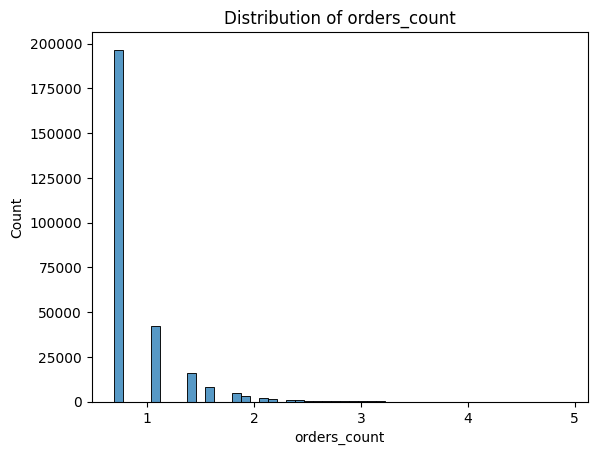

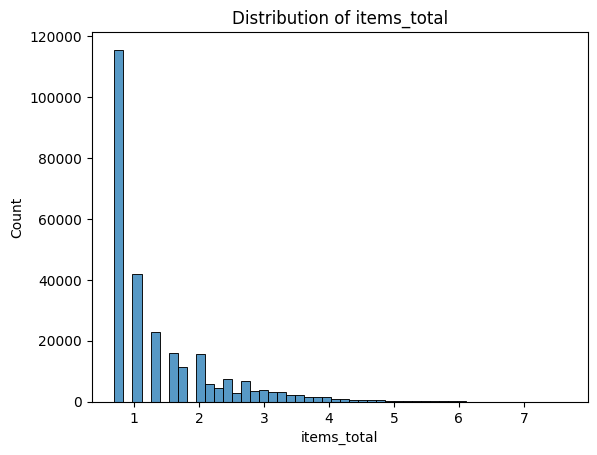

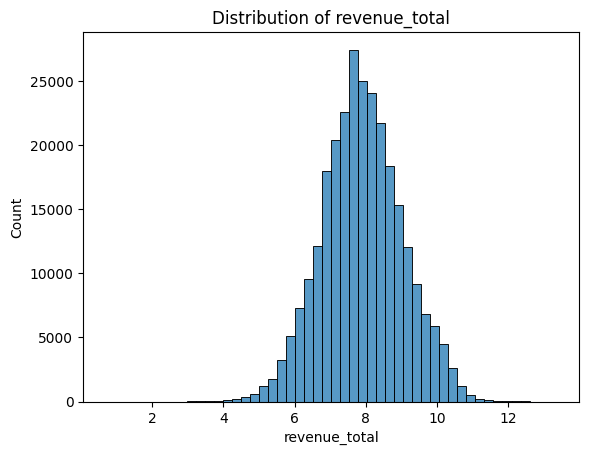

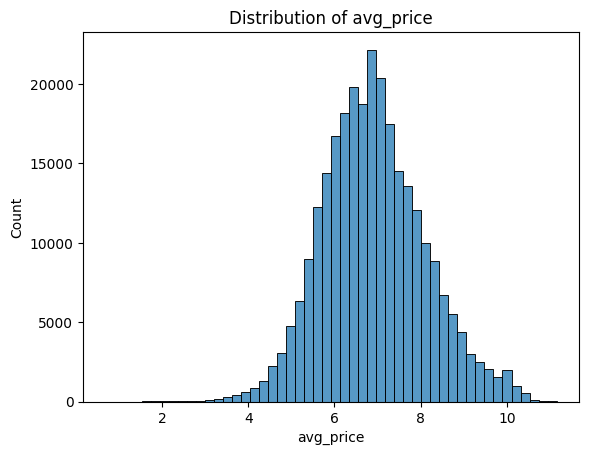

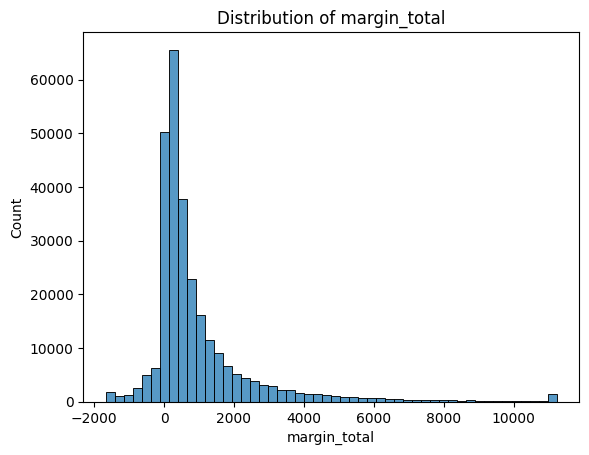

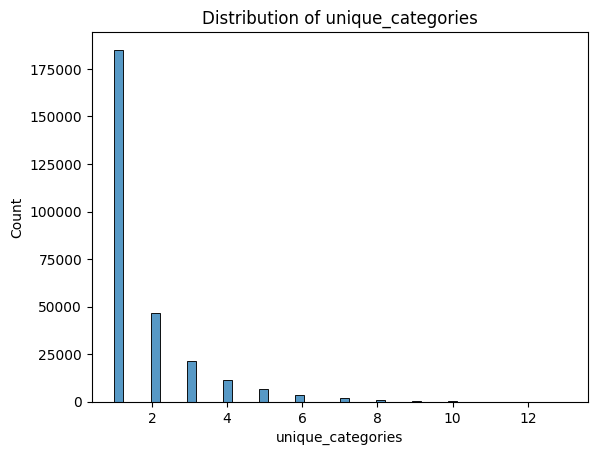

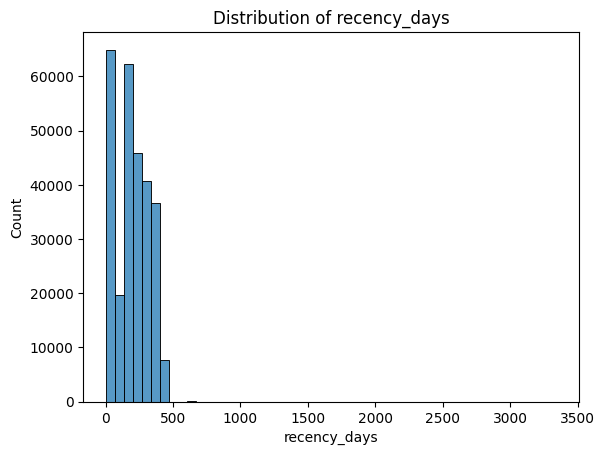

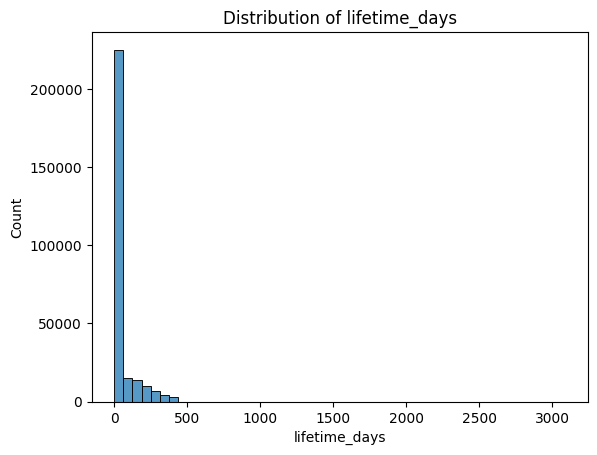

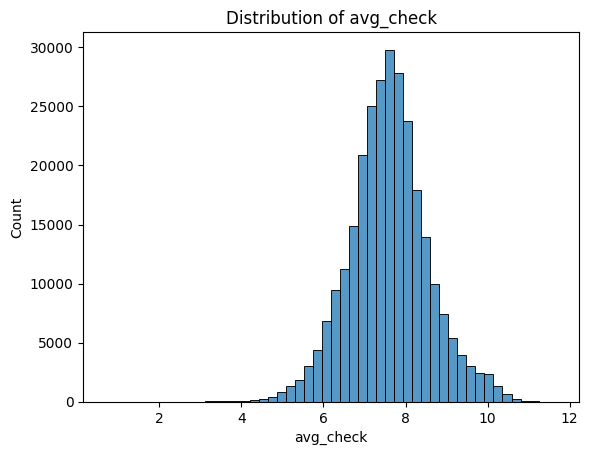

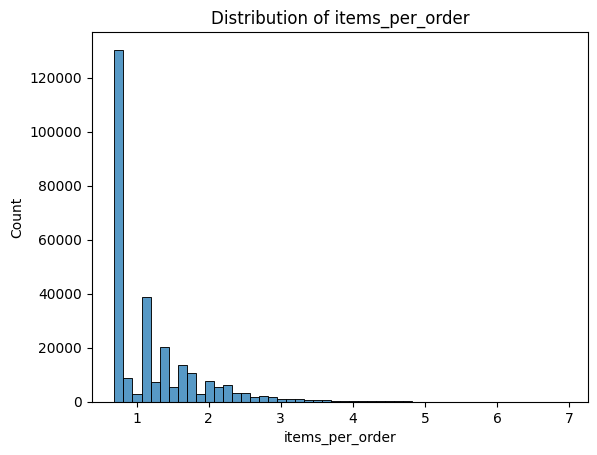

In [168]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(client_df[col], bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

In [169]:
#Логарифмируем колонки
log_cols = [
    'orders_count',
    'revenue_total',
    'items_total',
    'avg_check',
    'avg_price',
    'items_per_order'
]

for col in log_cols:
    client_df[col] = np.log1p(client_df[col])

In [170]:
for col in log_cols:
    print(col, client_df[col].min())

orders_count 0.5265890341390445
revenue_total 0.5265890341390445
items_total 0.5265890341390445
avg_check 0.5265890341390445
avg_price 0.5265890341390445
items_per_order 0.5265890341390445


In [171]:
print(client_df[numeric_cols].skew())

orders_count         1.831511
items_total          0.841069
revenue_total       -0.395496
avg_price           -0.315963
margin_total         3.125693
unique_categories    2.463665
recency_days         0.751829
lifetime_days        2.594264
avg_check           -0.399681
items_per_order      1.048141
dtype: float64


In [172]:
client_df['margin_total'].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

count    277805.000000
mean        974.566360
std        1669.298414
min       -1668.667600
50%         424.350000
90%        2656.988000
95%        4194.632000
99%        8835.764000
99.9%     11228.000000
max       11228.000000
Name: margin_total, dtype: float64

In [173]:
#Для margin_total обрежем хвост
lower = client_df['margin_total'].quantile(0.005)
upper = client_df['margin_total'].quantile(0.995)

client_df['margin_total'] = np.clip(
    client_df['margin_total'],
    lower,
    upper
)

In [174]:
client_df['margin_total'].skew()

np.float64(3.1256933765185893)

In [175]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277805 entries, 0 to 277804
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277805 non-null  object 
 1   orders_count       277805 non-null  float64
 2   items_total        277805 non-null  float64
 3   revenue_total      277805 non-null  float64
 4   avg_price          277805 non-null  float64
 5   margin_total       277805 non-null  float64
 6   unique_categories  277805 non-null  int64  
 7   recency_days       277805 non-null  int64  
 8   lifetime_days      277805 non-null  int64  
 9   avg_check          277805 non-null  float64
 10  items_per_order    277805 non-null  float64
 11  cluster_7          277805 non-null  int32  
 12  Месяц_Год          277735 non-null  object 
dtypes: float64(7), int32(1), int64(3), object(2)
memory usage: 26.5+ MB


In [176]:
num_cols = client_df.select_dtypes(include=['int', 'float']).columns

In [177]:
num_cols

Index(['orders_count', 'items_total', 'revenue_total', 'avg_price',
       'margin_total', 'unique_categories', 'recency_days', 'lifetime_days',
       'avg_check', 'items_per_order', 'cluster_7'],
      dtype='object')

In [178]:
corr_matrix = client_df[num_cols].corr(method='pearson')

corr_matrix.round(2)

,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order,cluster_7
orders_count,1.00,0.70,0.50,-0.15,0.29,0.69,-0.25,0.81,0.05,0.31,-0.19
items_total,0.70,1.00,0.42,-0.53,0.17,0.72,-0.19,0.56,0.11,0.90,0.14
revenue_total,0.50,0.42,1.00,0.54,0.61,0.41,-0.12,0.41,0.89,0.24,0.31
avg_price,-0.15,-0.53,0.54,1.00,0.41,-0.27,0.05,-0.12,0.70,-0.61,0.12
margin_total,0.29,0.17,0.61,0.41,1.00,0.26,-0.01,0.23,0.55,0.05,0.25
unique_categories,0.69,0.72,0.41,-0.27,0.26,1.00,-0.18,0.58,0.11,0.54,0.08
recency_days,-0.25,-0.19,-0.12,0.05,-0.01,-0.18,1.00,-0.33,-0.01,-0.10,0.28
lifetime_days,0.81,0.56,0.41,-0.12,0.23,0.58,-0.33,1.00,0.04,0.25,-0.29
avg_check,0.05,0.11,0.89,0.70,0.55,0.11,-0.01,0.04,1.00,0.12,0.46
items_per_order,0.31,0.90,0.24,-0.61,0.05,0.54,-0.10,0.25,0.12,1.00,0.31


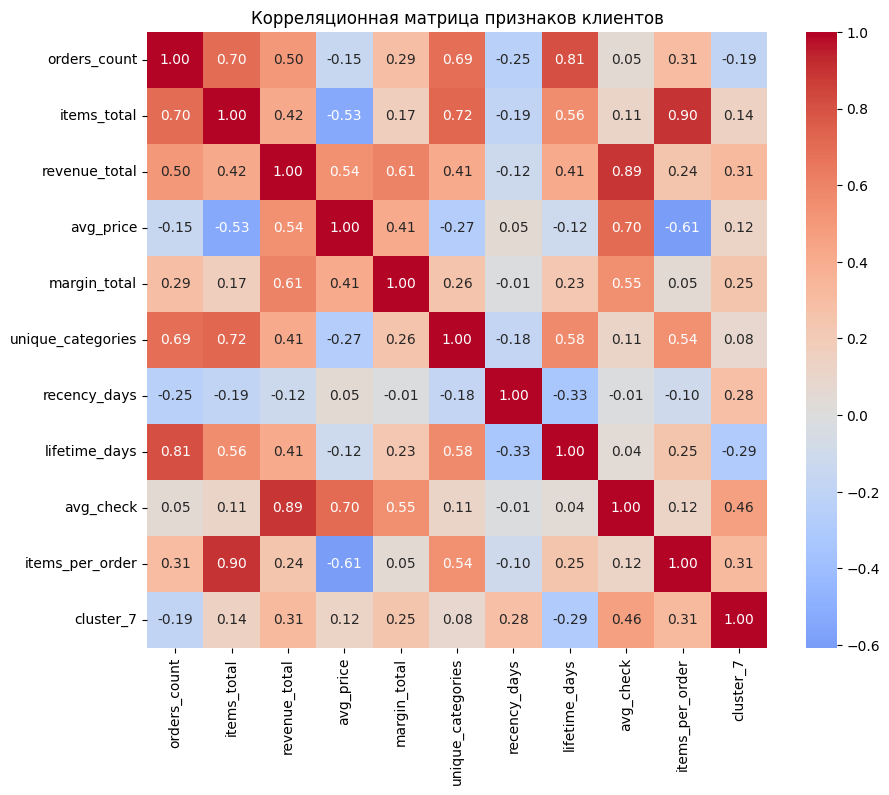

In [179]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Корреляционная матрица признаков клиентов")
plt.show()

In [180]:
features = [
    'orders_count',
    'items_per_order',
    'revenue_total',
    'avg_price',
    'margin_total',
    'unique_categories',
    'recency_days',
    'lifetime_days'
]

In [181]:
X = client_df[features].copy()

In [182]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

In [183]:
X_kmeans = X_scaled.copy()
X_em = X_scaled.copy()
X_hdbscan = X_scaled.copy()

In [184]:
inertia = []
ch_scores = []
db_scores = []

K_range = range(2, 20)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_kmeans)

    inertia.append(kmeans.inertia_)

    ch_scores.append(
        calinski_harabasz_score(X_kmeans, labels)
    )

    db_scores.append(
        davies_bouldin_score(X_kmeans, labels)
    )

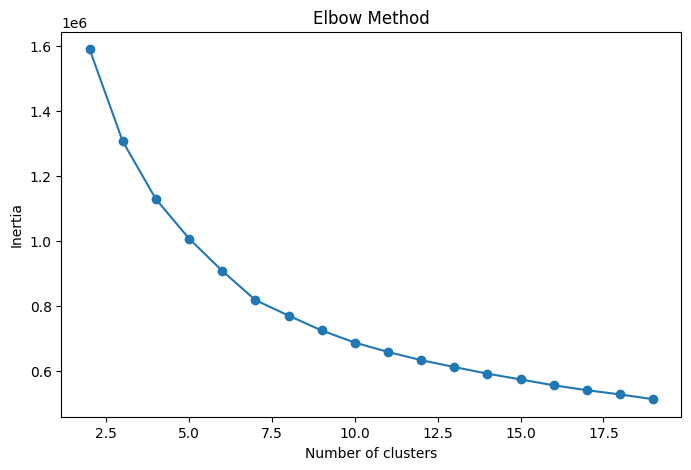

In [185]:
#метод локтя
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

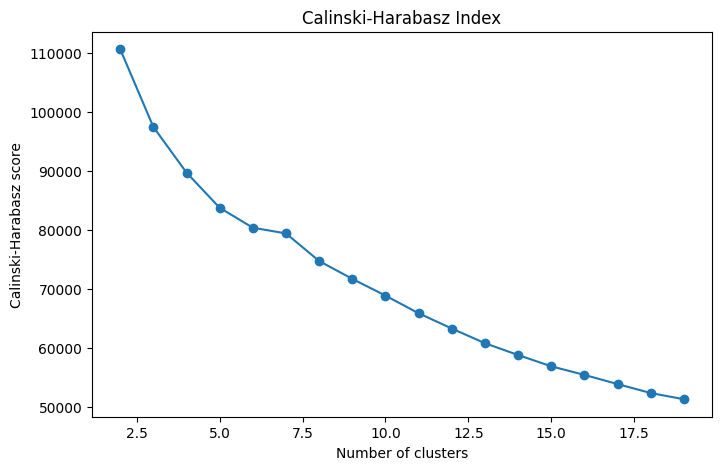

In [186]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, ch_scores, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz score')
plt.title('Calinski-Harabasz Index')

plt.show()

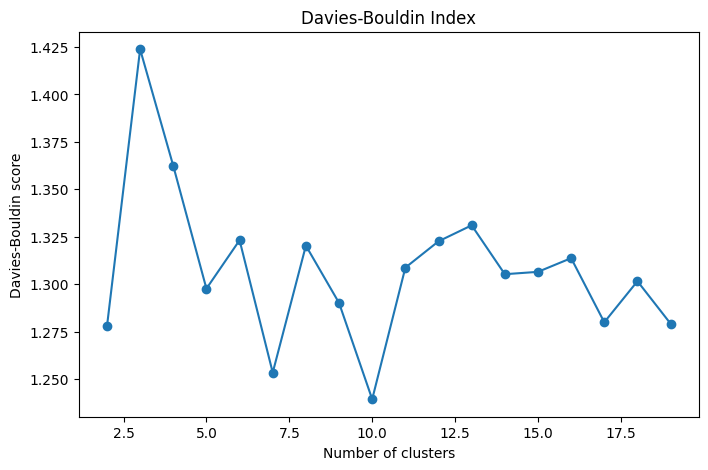

In [187]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, db_scores, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin score')
plt.title('Davies-Bouldin Index')

plt.show()

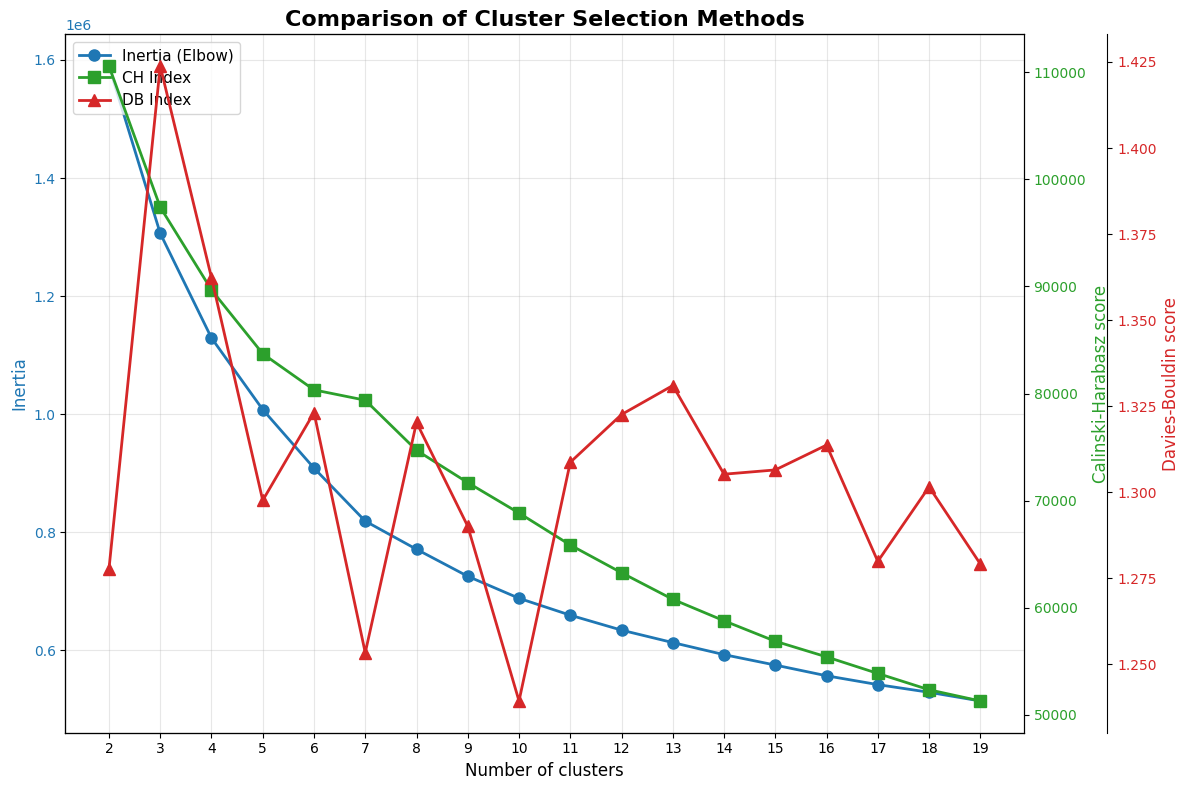

In [188]:
fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.set_xticks(K_range)
color = 'tab:blue'
ax1.set_xlabel('Number of clusters', fontsize=12)
ax1.set_ylabel('Inertia', color=color, fontsize=12)
line1 = ax1.plot(K_range, inertia, marker='o', color=color, linewidth=2, markersize=8, label='Inertia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Calinski-Harabasz score', color=color, fontsize=12)
line2 = ax2.plot(K_range, ch_scores, marker='s', color=color, linewidth=2, markersize=8, label='CH Index')
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color = 'tab:red'
ax3.set_ylabel('Davies-Bouldin score', color=color, fontsize=12)
line3 = ax3.plot(K_range, db_scores, marker='^', color=color, linewidth=2, markersize=8, label='DB Index')
ax3.tick_params(axis='y', labelcolor=color)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('Comparison of Cluster Selection Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [189]:
metrics_df = pd.DataFrame({
    'k': list(K_range),
    'inertia': inertia,
    'calinski_harabasz': ch_scores,
    'davies_bouldin': db_scores
})

metrics_df

,k,inertia,calinski_harabasz,davies_bouldin
0,2,1.589690e+06,110575.115649,1.277712
1,3,1.306353e+06,97405.302307,1.423807
2,4,1.129036e+06,89678.307447,1.362337
3,5,1.007722e+06,83716.121511,1.297647
4,6,9.085944e+05,80340.764607,1.323160
5,7,8.187662e+05,79375.144705,1.253397
6,8,7.710638e+05,74699.983429,1.320296
7,9,7.252847e+05,71679.556685,1.290123
8,10,6.880115e+05,68838.932035,1.239374
9,11,6.593670e+05,65853.075064,1.308711


* Davies-Bouldin - 2-е минимальное значение при k=7
* Elbow method - после 7 снижение инерции замедляется
* Calinski-Harabasz - хотя пик при k=2, после 7 падение стабилизируется

Исходя из этого, оптимальным выбором будет k=7

# K-means

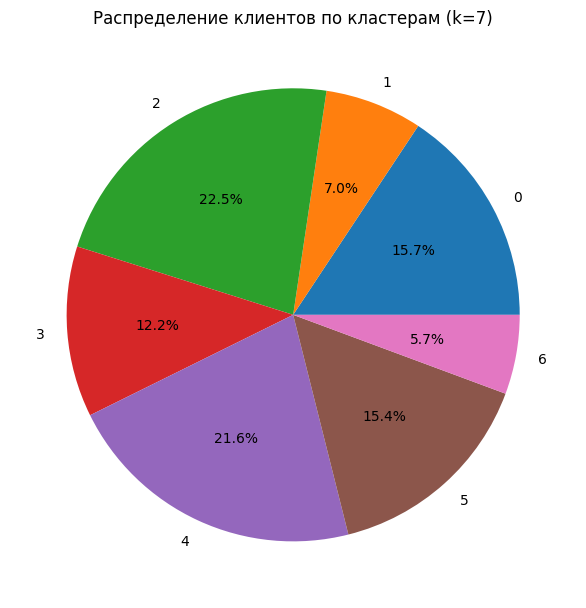

In [190]:
k_values = [7]

plt.figure(figsize=(16, 12))

for i, k in enumerate(k_values, 1):
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_kmeans)
    
    cluster_counts = (
        pd.Series(clusters)
        .value_counts()
        .sort_index()
    )
    
    client_df[f'cluster_{k}'] = clusters
    plt.subplot(2, 2, i)
    plt.pie(
        cluster_counts.values,
        labels=cluster_counts.index,
        autopct='%1.1f%%'
    )
    
    plt.title(f'Распределение клиентов по кластерам (k={k})')

plt.tight_layout()
plt.show()

In [191]:
#Составим портрет кластеров
def cluster_profile(df, features, cluster_col):
    
    # агрегаты по признакам
    profile = df.groupby(cluster_col)[features].agg(['mean', 'median']).round(2)
    
    # количество клиентов
    counts = df[cluster_col].value_counts().sort_index()
    total = len(df)
    
    # процент от общего числа
    share = (counts / total * 100).round(2)
    
    # добавляем в таблицу
    profile[('cluster_size', 'count')] = counts
    profile[('cluster_size', 'share_%')] = share
    
    return profile

In [192]:
cluster_col = 'cluster_7'

profile_7 = cluster_profile(client_df, features, cluster_col)

display(profile_7)

orders_count        items_per_order        revenue_total         \
                  mean median            mean median          mean median   
cluster_7                                                                   
0                 0.54   0.53            0.64   0.53          1.98   1.99   
1                 0.59   0.53            0.61   0.53          2.37   2.36   
2                 0.55   0.53            0.60   0.53          2.18   2.18   
3                 0.85   0.87            0.80   0.79          2.26   2.26   
4                 0.55   0.53            0.61   0.53          2.17   2.16   
5                 0.59   0.53            1.13   1.10          2.18   2.18   
6                 1.06   1.03            1.06   1.05          2.36   2.36   

          avg_price        margin_total          unique_categories         \
               mean median         mean   median              mean median   
cluster_7                                                                   
0              1.92   1.94       127.41   117.09              1.09    1.0   
1              2.32   2.32      4974.97  4190.70              1.28    1.0   
2              2.14   2.14       659.55   508.21              1.12    1.0   
3              2.04   2.04       926.29   760.56              2.32    2.0   
4              2.13   2.12       439.08   317.90              1.10    1.0   
5              1.90   1.91       531.07   393.50              2.22    2.0   
6              1.97   1.97      3017.24  2319.46              5.25    5.0   

          recency_days        lifetime_days        cluster_size          
                  mean median          mean median        count share_%  
cluster_7                                                                
0               229.06  227.0          1.84    0.0        43595   15.69  
1               222.86  225.0         16.85    0.0        19317    6.95  
2               314.20  317.0          3.66    0.0        62440   22.48  
3               124.68  134.0        169.87  156.0        33852   12.19  
4                86.74   49.0          2.41    0.0        60039   21.61  
5               205.27  204.0         11.70    0.0        42842   15.42  
6               100.27  120.0        232.36  231.0        15720    5.66

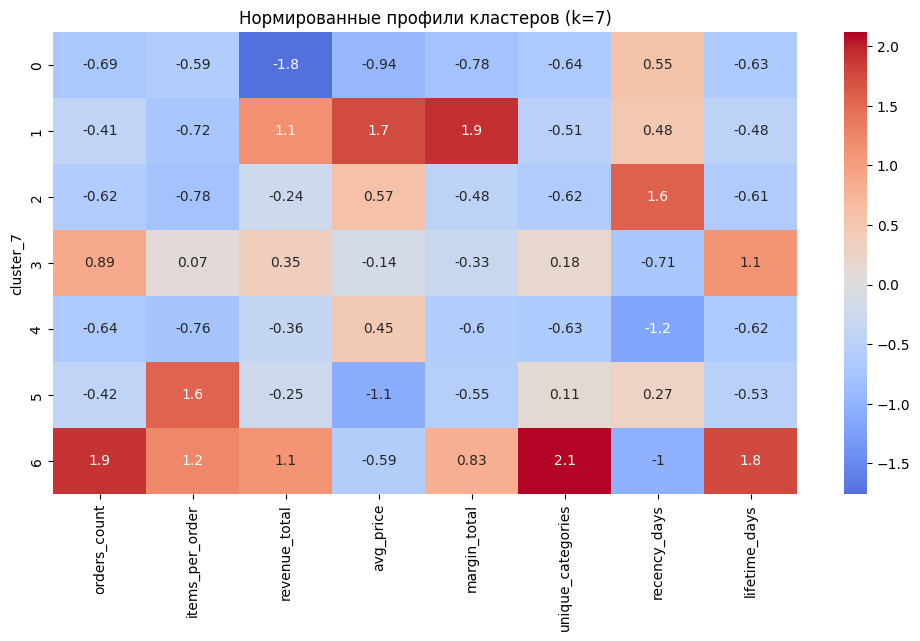

In [193]:
means = client_df.groupby('cluster_7')[features].mean().astype(float)

means_scaled = (means - means.mean()) / means.std()

plt.figure(figsize=(12,6))
sns.heatmap(means_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Нормированные профили кластеров (k=7)")
plt.show()

In [194]:
result = client_df.groupby('cluster_7')[features].mean().astype(float).round(2)
result['%_клиентов'] = (client_df['cluster_7'].value_counts(normalize=True) * 100).round(2).sort_index()
result.to_excel('clusters_with_pct.xlsx')

* ordes_count — количество заказов
* items_per_order — товаров в заказе
* revenue_total — общая выручка
* avg_price — средний чек / цена
* margin_total — общая маржинальность
* unique_categories — уникальных категорий
* recent_days — давность последней покупки (чем меньше, тем лучше / активнее)
* lifetime_days — длительность жизни клиента

**Кластер 0**
* Минимальное количество категорий (-1.5), низкая маржа (-0.76), низкий средний чек (-0.78)
* Высокая давность (1.1) — давно не покупали
* Спящие / отточные клиенты с узким ассортиментом

**Кластер 1**
* Высокий lifetime_days (1.1), выше среднего заказы (0.69), средний чек чуть ниже (-0.3)
* Недавно покупали (-0.68)
* Стабильные старые клиенты
  
**Кластер 2**
* Очень высокий avg_price (1.8), высокая маржа (2.0), много категорий (1.3)
* Низкая частота заказов (-0.4) и низкая давность (0.42 — плохо)
* Дорогие, но редкие клиенты — возможно, премиум, но теряют активность

**Кластер 3**
* ВСЕ признаки сильно ниже среднего (почти все отрицательные, кроме avg_price близкого к 0)
* Очень низкая давность (-1.2) — давно не покупали
* Кандидаты на отток — неактивные, с низкими показателями

**Кластер 4**
* Очень высокая частота заказов (2.0) и высокий средний чек (1.2), высокая маржа (0.73), много категорий (2.1)
* Недавно покупали 
* Частые, дорогие, маржинальные, лояльные

**Кластер 5**
* Выше среднего avg_price (0.82), выше среднего lifetime_days (1.2)
* Остальное — ниже среднего
* Скорее всего — клиенты с высоким чеком, но редкими покупками, старые

**Кластер 6**
* Очень низкие заказы (-0.39), низкий средний чек (-0.99), низкая маржа (-0.54)
* Высокое items_per_order (1.8) — покупают много товаров за раз, но редко
* Слабая давность (0.25) — давно не покупали
* Скорее всего — редкие, но оптовые/семейные покупатели с низкой маржой


**Итог**
* Топ (частые, дорогие) -	4
* Дорогие, но редкие	- 2, 5
* Массовые / средние - 1
* Редкие / оптовые - 6
* Отточные / неактивные - 3, 0

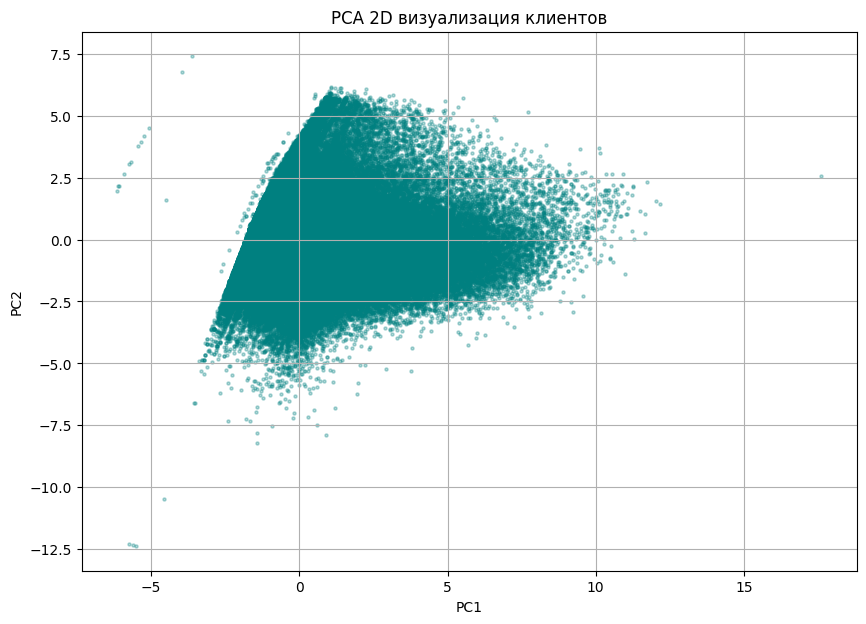

Доля объясненной дисперсии: PC1 = 0.41, PC2 = 0.25, PC1+PC2 = 0.66


In [195]:
#PCA
X_plot = X_kmeans.copy() 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_plot)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Визуализация
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=5, alpha=0.3, color='teal')
plt.title('PCA 2D визуализация клиентов')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

explained_var = pca.explained_variance_ratio_
print(f"Доля объясненной дисперсии: PC1 = {explained_var[0]:.2f}, PC2 = {explained_var[1]:.2f}, PC1+PC2 = {explained_var[0]+explained_var[1]:.2f}")

# HDBSCAN


Распределение клиентов по кластерам (HDBSCAN):
cluster_hdbscan
-1     28520
 0     72946
 1      1643
 2      5618
 3     19869
 4     89889
 5     21958
 6      4706
 7     16745
 8      1509
 9      1719
 10     5953
 11     6730
Name: count, dtype: int64
Процент клиентов, относящихся к шуму: 10.27%


/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/2113261620.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_hdbscan', data=client_clusters, palette='tab10', order=cluster_counts.index)


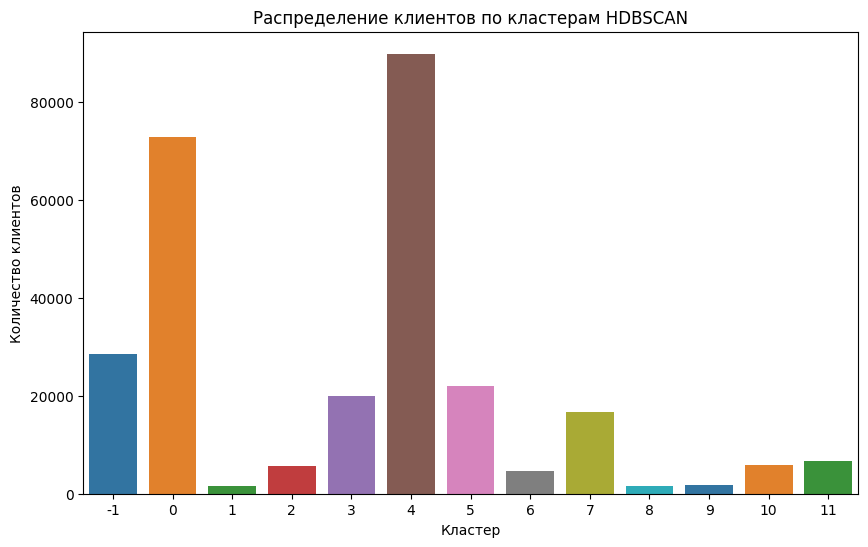

In [196]:
# Настройка HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,   # минимальный размер кластера
    min_samples=50,         # чувствительность к шуму
    metric='euclidean',
    cluster_selection_method='eom'
)

# Обучаем модель
cluster_labels = clusterer.fit_predict(X_hdbscan)

# Добавляем метки в датафрейм клиентов
client_clusters = client_df.copy()
client_clusters['cluster_hdbscan'] = cluster_labels

# Посмотрим распределение по кластерам
cluster_counts = client_clusters['cluster_hdbscan'].value_counts().sort_index()
print("Распределение клиентов по кластерам (HDBSCAN):")
print(cluster_counts)

# Процент клиентов, которые HDBSCAN считает шумом (-1)
noise_pct = (cluster_counts.get(-1, 0) / len(client_clusters)) * 100
print(f"Процент клиентов, относящихся к шуму: {noise_pct:.2f}%")

# Визуализация распределения кластеров
plt.figure(figsize=(10,6))
sns.countplot(x='cluster_hdbscan', data=client_clusters, palette='tab10', order=cluster_counts.index)
plt.title('Распределение клиентов по кластерам HDBSCAN')
plt.xlabel('Кластер')
plt.ylabel('Количество клиентов')
plt.show()

/Users/ekaterinazinoveva/Mag/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


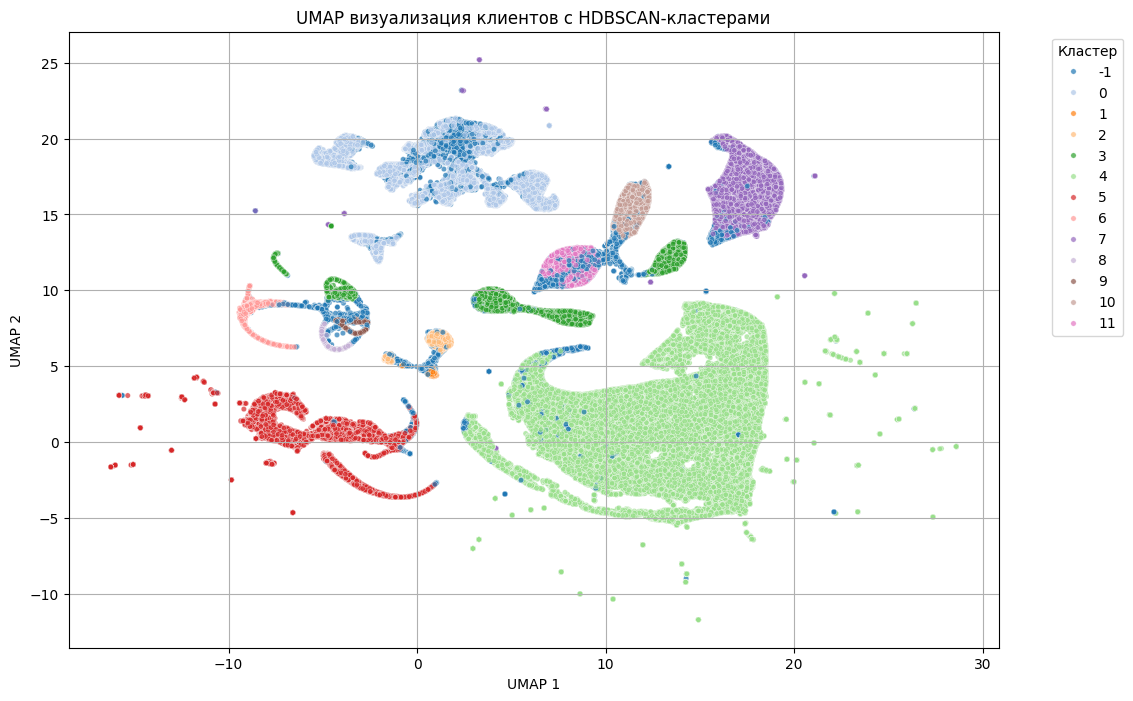

In [197]:
X_umap = X_scaled.copy() 

# UMAP
reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=50,       
    min_dist=0.0,         
    metric='euclidean', 
    random_state=42
)
X_embedded = reducer.fit_transform(X_umap)

umap_df = pd.DataFrame(X_embedded, columns=['UMAP1', 'UMAP2'])
umap_df['cluster'] = client_clusters['cluster_hdbscan'].values

plt.figure(figsize=(12,8))
palette = sns.color_palette("tab20", n_colors=len(umap_df['cluster'].unique()))
sns.scatterplot(
    x='UMAP1', y='UMAP2', 
    hue='cluster', 
    data=umap_df, 
    palette=palette,
    legend='full',
    s=15,
    alpha=0.7
)
plt.title('UMAP визуализация клиентов с HDBSCAN-кластерами')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

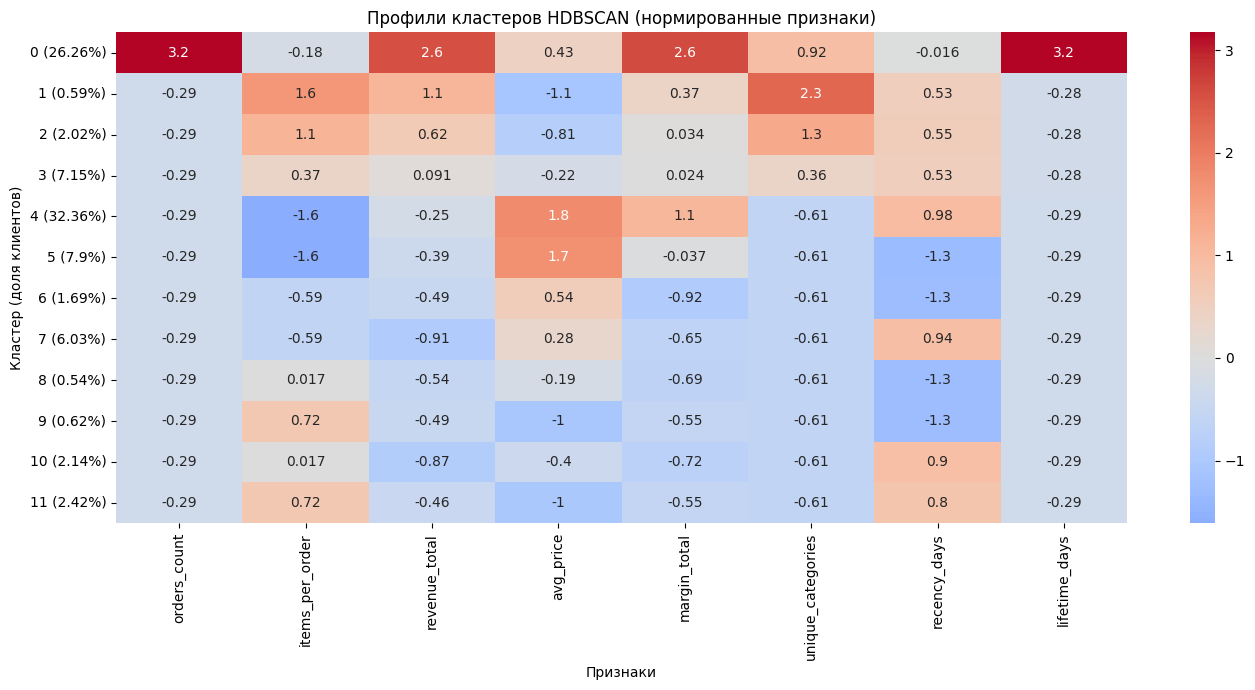

In [198]:
# убираем шум
df_hdb = client_clusters[client_clusters['cluster_hdbscan'] != -1].copy()

# средние значения
means_hdb = df_hdb.groupby('cluster_hdbscan')[features].mean().astype(float)

# нормализация ПО СТОЛБЦАМ
means_scaled = (means_hdb - means_hdb.mean()) / means_hdb.std()

# доля клиентов (без шума)
cluster_sizes = df_hdb['cluster_hdbscan'].value_counts().sort_index()
cluster_share = (cluster_sizes / len(client_clusters) * 100).round(2)

# добавляем % в название кластера
new_index = [
    f"{cluster} ({cluster_share[cluster]}%)"
    for cluster in means_scaled.index
]

means_scaled.index = new_index

plt.figure(figsize=(14, 7))

sns.heatmap(
    means_scaled,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Профили кластеров HDBSCAN (нормированные признаки)")
plt.xlabel("Признаки")
plt.ylabel("Кластер (доля клиентов)")
plt.tight_layout()
plt.show()

Кластер 0 (22,06%) имеет максимальные значения по количеству заказов (+3,61) и длительности жизни клиента (+3,61). Кластер 1 (0,54%) показывает наибольшую широту категорий (+2,69) и количество товаров в заказе (+1,83). Кластер 5 (9,63%) лидирует по среднему чеку (+2,43) и маржинальности (+2,31). При этом кластер 10 (0,22%) имеет минимальную маржинальность (-2,37), а кластеры 7, 9, 10, 11, 12 демонстрируют самые низкие показатели давности покупки (от -1,11 до -1,20), что указывает на давно неактивных клиентов.

# EM-кластеризация

In [199]:
#Подбор числа кластеров
K_range = range(2, 15)
bic_scores = []
aic_scores = []

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_em)
    
    bic_scores.append(gmm.bic(X_em))
    aic_scores.append(gmm.aic(X_em))

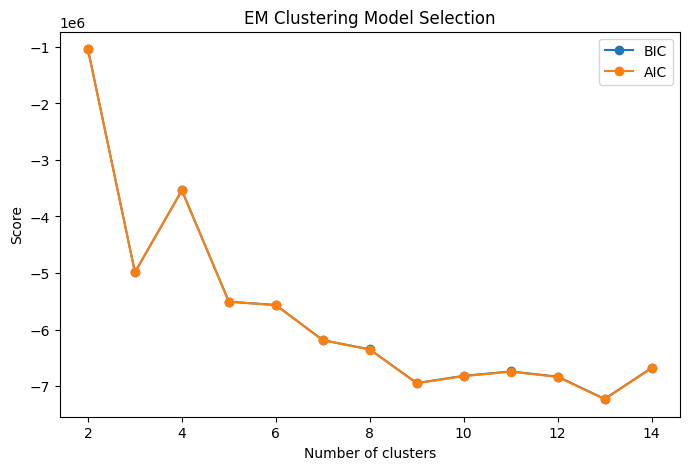

In [200]:
#Оптимальное число кластеров - BIC/AIC минимальны
plt.figure(figsize=(8,5))
plt.plot(K_range, bic_scores, marker='o', label='BIC')
plt.plot(K_range, aic_scores, marker='o', label='AIC')

plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.title('EM Clustering Model Selection')
plt.legend()

plt.show()

In [201]:
#Подбираем лучший тип ковариации
covariance_types = ['full', 'tied', 'diag', 'spherical']
best_score = -1
best_params = {}

for cov_type in covariance_types:
    # Подбираем число кластеров для каждого типа
    K_range = range(2, 15)
    bic_scores = []
    
    for k in K_range:
        gmm = GaussianMixture(n_components=k, covariance_type=cov_type, 
                             random_state=42, n_init=10)
        gmm.fit(X_em)
        bic_scores.append(gmm.bic(X_em))
    
    optimal_k = K_range[np.argmin(bic_scores)]
    
    # Оцениваем качество
    gmm = GaussianMixture(n_components=optimal_k, covariance_type=cov_type, 
                         random_state=42, n_init=10)
    clusters = gmm.fit_predict(X_em)
    score = silhouette_score(X_em, clusters)
    
    print(f"{cov_type}: k={optimal_k}, silhouette={score:.4f}")
    
    if score > best_score:
        best_score = score
        best_params = {'cov_type': cov_type, 'n_components': optimal_k}


full: k=13, silhouette=0.0156
tied: k=13, silhouette=0.1544
diag: k=14, silhouette=0.0744
spherical: k=14, silhouette=0.1370


In [202]:
gmm = GaussianMixture(
    n_components=14,  
    covariance_type='tied',
    random_state=42,
    n_init=10,
    max_iter=500
)
clusters_em = gmm.fit_predict(X_em)
client_df['cluster_em'] = clusters_em

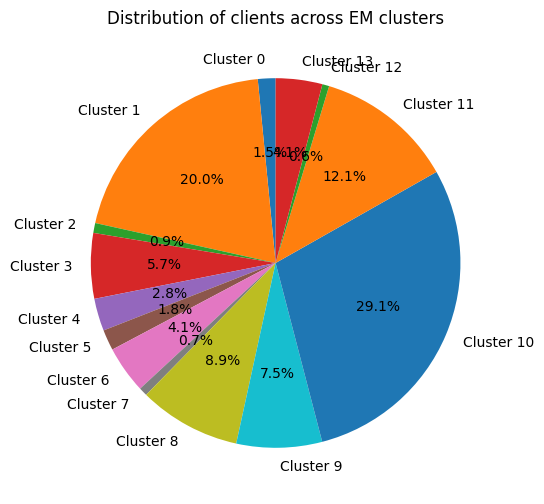

In [203]:
cluster_counts_em = client_df['cluster_em'].value_counts().sort_index()

plt.figure(figsize=(6,6))

plt.pie(cluster_counts_em,
        labels=[f'Cluster {i}' for i in cluster_counts_em.index],
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribution of clients across EM clusters')
plt.show()

In [204]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277805 entries, 0 to 277804
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277805 non-null  object 
 1   orders_count       277805 non-null  float64
 2   items_total        277805 non-null  float64
 3   revenue_total      277805 non-null  float64
 4   avg_price          277805 non-null  float64
 5   margin_total       277805 non-null  float64
 6   unique_categories  277805 non-null  int64  
 7   recency_days       277805 non-null  int64  
 8   lifetime_days      277805 non-null  int64  
 9   avg_check          277805 non-null  float64
 10  items_per_order    277805 non-null  float64
 11  cluster_7          277805 non-null  int32  
 12  Месяц_Год          277735 non-null  object 
 13  cluster_em         277805 non-null  int64  
dtypes: float64(7), int32(1), int64(4), object(2)
memory usage: 28.6+ MB


In [205]:
cols_to_drop = ['cluster_7']
numeric_df = client_df.select_dtypes(include='number').drop(columns=cols_to_drop, errors='ignore')

In [206]:
cluster_profiles = numeric_df.groupby('cluster_em').mean()

In [207]:
print(cluster_profiles.dtypes)

orders_count         float64
items_total          float64
revenue_total        float64
avg_price            float64
margin_total         float64
unique_categories    float64
recency_days         float64
lifetime_days        float64
avg_check            float64
items_per_order      float64
dtype: object


In [208]:
cluster_profiles = cluster_profiles.astype(float)

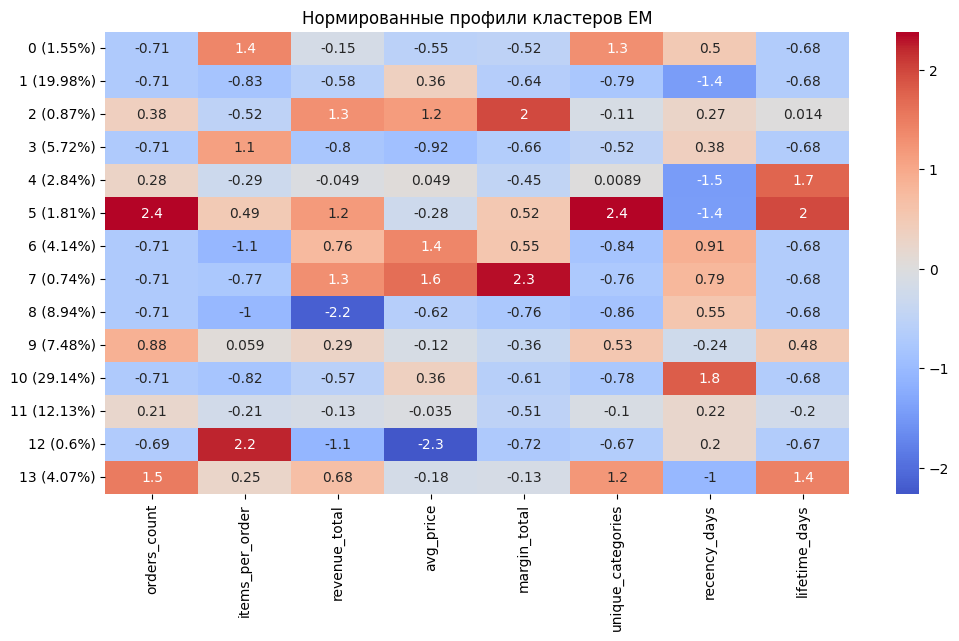

In [209]:

cluster_em_sizes = client_df['cluster_em'].value_counts().sort_index()
cluster_em_share = (cluster_em_sizes / len(client_df) * 100).round(2)

means_em = client_df.groupby('cluster_em')[features].mean().astype(float)

means_em.index = [f"{cluster} ({cluster_em_share[cluster]}%)" for cluster in means_em.index]

means_em_scaled = (means_em - means_em.mean()) / means_em.std()

# Тепловая карта
plt.figure(figsize=(12,6))
sns.heatmap(means_em_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Нормированные профили кластеров EM")
plt.show()

In [210]:
means_em_scaled.to_excel('тепловая_карта_EM.xlsx')

**Кластер 0 (0.65%)** — элитный сегмент: максимальные заказы (+2.31), высокая выручка (+1.66), максимальная маржинальность (+1.94), широкий ассортимент (+1.95), свежие покупки (-1.13), давние клиенты (+1.63).

**Кластер 1 (19.28%)** — массовый неактивный сегмент: низкие заказы (-0.80), выручка (-0.67), маржинальность (-0.61), узкий ассортимент (-0.87), но недавно активны (-1.07).

**Кластер 2 (1.21%)** — премиум-сегмент: максимальный средний чек (+1.99), максимальная маржинальность (+2.43), высокая выручка (+1.48), узкий ассортимент (-0.55).

**Кластер 3 (7.64%)** — средний сегмент: показатели близки к средним, небольшая длительность жизни (+0.56).

**Кластер 4 (33.55%)** — самый крупный спящий сегмент: минимальная выручка (-1.08), мало заказов (-0.70), узкий ассортимент (-0.78), высокая давность покупок (+1.36).

**Кластер 5 (4.21%)** — премиум-сегмент: высокий средний чек (+1.75), высокая маржинальность (+0.73), мало товаров в заказе (-0.93).

**Кластер 6 (1.8%)** — активный сегмент: много заказов (+1.55), широкий ассортимент (+1.64), свежие покупки (-1.21), давние клиенты (+1.63).

**Кластер 7 (2.56%)** — активный сегмент: хорошие заказы (+1.03), широкий ассортимент (+1.19), средние показатели по остальным метрикам.

**Кластер 8 (8.77%)** — проблемный сегмент: минимальная выручка (-2.12), самый низкий средний чек (-0.99), крайне низкие показатели по всем метрикам.

**Кластер 9 (3.24%)** — лояльный сегмент: максимальная длительность жизни (+1.81), самые свежие покупки (-1.44), средние заказы.

**Кластер 10 (3.1%)** — нишевый сегмент: много товаров в заказе (+0.84), широкий ассортимент (+0.82), низкая выручка.

**Кластер 11 (9.68%)** — ушедший сегмент: максимальная давность покупок (+1.89), мало товаров в заказе (-1.27), узкий ассортимент (-0.94).

**Кластер 12 (3.19%)** — нишевый сегмент: очень много товаров в заказе (+1.48), низкий средний чек (-1.12).

**Кластер 13 (1.13%)** — нишевый сегмент: максимальное количество товаров в заказе (+2.28), низкий средний чек (-1.02).

In [211]:
# KMeans (k=7)
sil_kmeans = silhouette_score(X_kmeans, client_df['cluster_7'])
print("Silhouette KMeans:", sil_kmeans)

# HDBSCAN (без шума)
mask_hdb = client_clusters['cluster_hdbscan'] != -1
sil_hdb = silhouette_score(
    X_hdbscan[mask_hdb],
    client_clusters.loc[mask_hdb, 'cluster_hdbscan']
)
print("Silhouette HDBSCAN:", sil_hdb)


# EM (Gaussian Mixture)
sil_em = silhouette_score(X_em, client_df['cluster_em'])
print("Silhouette EM:", sil_em)

Silhouette KMeans: 0.2260024189236908
Silhouette HDBSCAN: 0.00500413512005704
Silhouette EM: 0.1514533655590291


In [227]:
#Добавляем кластеры в исходный датасет
df = df.merge(client_df[['Телефон_new', 'cluster_7']], 
              on='Телефон_new', 
              how='left')

In [228]:
df.head()

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,ДатаЗаказаНаСайте,Телефон_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,МесяцЗаказа,Месяц_Год,year,cluster_7
0,2017-01-01 17:38:00,2017-01-04,3530318_TR,Доставлен,2510.0,2510.0,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,2017-01-02,55575054-56575354545171,Гость,IDL00035301654,0,NaN,1,2017-01-01,2017,6
1,2017-01-01 17:56:00,2017-01-04,3530350_TR,Доставлен,2399.0,2399.0,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,2017-01-02,55575453-50495352485179,Гость,IDL00018185654,0,NaN,1,2017-01-01,2017,2
2,2017-01-01 18:55:00,2017-01-12,3530471_TR,Доставлен,1328.0,1328.0,Магазины,Безналичная,Москва,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",...,2017-01-02,55575456-54565557484873,Гость,IDL00002322654,0,NaN,1,2017-01-01,2017,2
3,2017-01-01 19:13:00,2017-01-11,3530517_TR,Доставлен,1948.0,1948.0,Магазины,Безналичная,Москва,КРУПНОГАБАРИТНЫЙ ТОВАР,...,2017-01-02,55574851-55575657565273,Гость,IDL00022368654,0,NaN,1,2017-01-01,2017,3
4,2017-01-01 19:30:00,2017-01-19,3530615_TR,Доставлен,366.0,366.0,Магазины,Безналичная,Барнаул,ИГРУШКИ,...,2017-01-02,55574854-57545652574976,Гость,IDL00007574856,0,NaN,1,2017-01-01,2017,3


In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1393343 entries, 0 to 1393342
Data columns (total 40 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   Дата                      1393343 non-null  datetime64[ns]
 1   ДатаДоставки              1393343 non-null  datetime64[ns]
 2   НомерЗаказаНаСайте        1393343 non-null  object        
 3   НовыйСтатус               1393343 non-null  category      
 4   СуммаЗаказаНаСайте        1393343 non-null  float64       
 5   СуммаДокумента            1393343 non-null  float64       
 6   МетодДоставки             1393343 non-null  category      
 7   ФормаОплаты               1393343 non-null  category      
 8   Регион                    1379232 non-null  category      
 9   Группа2                   1393343 non-null  category      
 10  Группа3                   1393343 non-null  category      
 11  Группа4                   1335893 non-null  catego

In [215]:
client_df.head()

,Телефон_new,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order,cluster_7,Месяц_Год,cluster_em
0,32555749-545749525150 .,0.526589,1.026672,2.072791,1.847096,174.66,1,327,0,2.072791,1.026672,5,"[2017-04, 2017-04, 2017-04, 2017-04, 2017-04]",3
1,49574954-56524849545119,0.526589,0.526589,2.256546,2.256546,-704.86,1,191,0,2.256546,0.526589,4,[2017-08],10
2,51534957-48525550515032,0.526589,0.869742,2.067591,1.914541,262.00,1,233,0,2.067591,0.869742,0,"[2017-07, 2017-07]",10
3,55494851-56495152535476,0.526589,0.526589,2.127868,2.127868,376.02,1,343,0,2.127868,0.526589,2,[2017-03],10
4,55515349-57484951525673,0.526589,0.526589,2.104731,2.104731,-186.00,1,181,0,2.104731,0.526589,4,[2017-08],10


In [226]:
df = df.drop('cluster_7_x', axis=1)

In [216]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277805 entries, 0 to 277804
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277805 non-null  object 
 1   orders_count       277805 non-null  float64
 2   items_total        277805 non-null  float64
 3   revenue_total      277805 non-null  float64
 4   avg_price          277805 non-null  float64
 5   margin_total       277805 non-null  float64
 6   unique_categories  277805 non-null  int64  
 7   recency_days       277805 non-null  int64  
 8   lifetime_days      277805 non-null  int64  
 9   avg_check          277805 non-null  float64
 10  items_per_order    277805 non-null  float64
 11  cluster_7          277805 non-null  int32  
 12  Месяц_Год          277735 non-null  object 
 13  cluster_em         277805 non-null  int64  
dtypes: float64(7), int32(1), int64(4), object(2)
memory usage: 28.6+ MB


In [217]:
client_df = client_df.drop('cluster_em', axis=1)

In [218]:
client_df = client_df.drop('Месяц_Год', axis=1)

In [219]:
for col in client_df.select_dtypes(include=['Float64']).columns:
    client_df[col] = client_df[col].astype('float64')

In [220]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277805 entries, 0 to 277804
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277805 non-null  object 
 1   orders_count       277805 non-null  float64
 2   items_total        277805 non-null  float64
 3   revenue_total      277805 non-null  float64
 4   avg_price          277805 non-null  float64
 5   margin_total       277805 non-null  float64
 6   unique_categories  277805 non-null  int64  
 7   recency_days       277805 non-null  int64  
 8   lifetime_days      277805 non-null  int64  
 9   avg_check          277805 non-null  float64
 10  items_per_order    277805 non-null  float64
 11  cluster_7          277805 non-null  int32  
dtypes: float64(7), int32(1), int64(3), object(1)
memory usage: 24.4+ MB


In [221]:
client_df.to_parquet('client_data.parquet', 
                     engine='fastparquet', 
                     index=False)

In [222]:
period_cols = []
for col in df.columns:
    if pd.api.types.is_period_dtype(df[col]):
        period_cols.append(col)
        print(f"  {col}: {df[col].dtype}")
for col in period_cols:
    df[col] = df[col].dt.to_timestamp()

  Месяц_Год: period[M]


/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/2643321456.py:3: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):


In [230]:
df.to_parquet('df.parquet', 
                     engine='fastparquet', 
                     index=False)

In [133]:

!/Users/ekaterinazinoveva/Mag/bin/pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.1/692.1 kB 487.0 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 693.2 kB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fastparquet]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/ekaterinazinoveva/Mag/bin/python3.14 -m pip install --upgrade pip


In [233]:
print(f"Диапазон дат: {df['ДатаЗаказаНаСайте'].min()} - {df['ДатаЗаказаНаСайте'].max()}")

Диапазон дат: 2017-01-01 00:00:00 - 2018-02-28 00:00:00
